# ADEF

Adaptive Evidential Fusion (ADEF) with Co-Attention

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models
from transformers import RobertaTokenizer, RobertaModel

from PIL import Image
import pandas as pd
import numpy as np
import os
import warnings
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ============================================================
# REPRODUCIBILITY
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("\u2705 Imports loaded & seed set.")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


C:\Users\Residensi ADW\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports loaded & seed set.
PyTorch version: 2.5.1
CUDA available: True
GPU: NVIDIA GeForce RTX 3060


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

class CFG:

    # =========================
    # PATH
    # =========================
    ROOT_DIR = r"D:/MVSA_SINGLE"
    DATA_DIR = r"D:/MVSA_SINGLE/data"
    LABEL_PATH = r"D:/MVSA_SINGLE/labelResultAllFinal.txt"

    # =========================
    # DEVICE
    # =========================
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    # =========================
    # HYPERPARAMETERS
    # =========================
    BATCH_SIZE = 16
    EPOCHS = 30
    LR = 2e-5
    WEIGHT_DECAY = 1e-4
    MAX_LEN = 150
    D_BERT = 768
    D_CNN = 1024
    D_PROJ = 512
    NUM_CLASSES = 3
    ANNEALING_EPOCHS = 10  # KL reaches full strength at epoch 10 (1/3 of training)
    SEED = 42
    DROPOUT = 0.3

    # =========================
    # ADEF-SPECIFIC
    # =========================
    CONFLICT_THRESHOLD = 0.5  # tau: conflict routing threshold
    GAMMA = 1.0               # gamma: conflict loss balancing weight

    # =========================
    # PRETRAINED MODELS
    # =========================
    TEXT_MODEL = "roberta-base"
    IMAGE_MODEL = "densenet121"

print(f"\u2705 Configuration loaded. Device: {CFG.DEVICE}")


✅ Configuration loaded. Device: cuda


In [3]:
import pandas as pd
import os
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(CFG.LABEL_PATH, header=0, sep=",")
df.columns = ["id", "text_label", "image_label", "final_label"]

def is_valid(row):

    if row["text_label"] == "positive" and row["image_label"] == "negative":
        return False

    if row["text_label"] == "negative" and row["image_label"] == "positive":
        return False

    return True

df = df[df.apply(is_valid, axis=1)]
df = df.reset_index(drop=True)

print(f"Dataset size after filtering: {len(df)}")

label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

df["label"] = df["final_label"].map(label_map)

# Load text file dengan better error handling
def load_text(sample_id):
    path = os.path.join(CFG.DATA_DIR, f"{sample_id}.txt")

    encodings = ["utf-8", "latin-1", "cp1252", "iso-8859-1"]

    for encoding in encodings:
        try:
            with open(path, "r", encoding=encoding) as f:
                text = f.read().strip()
                if text:  # Jika text berhasil dibaca dan tidak kosong
                    return text
        except FileNotFoundError:
            continue
        except Exception as e:
            continue

    # Jika semua encoding gagal atau file tidak ada
    return ""

# Track failed samples for debugging
failed_samples = []

df["text"] = df["id"].apply(load_text)

# Hitung empty text
empty_text_count = (df["text"] == "").sum()
print(f"\n{'='*60}")
print(f"PREPROCESSING STATISTICS:")
print(f"{'='*60}")
print(f"Total samples: {len(df)}")
print(f"Samples with EMPTY text: {empty_text_count}")
print(f"Samples with VALID text: {len(df) - empty_text_count}")
print(f"Percentage of empty text: {(empty_text_count/len(df)*100):.2f}%")
print(f"{'='*60}\n")

if empty_text_count > 0:
    print("IDs with empty text:")
    empty_ids = df[df["text"] == ""]["id"].tolist()
    for idx in empty_ids[:10]:  # Show first 10
        print(f"  - {idx}")
    if len(empty_ids) > 10:
        print(f"  ... and {len(empty_ids) - 10} more")
    print()

# image path
df["image_path"] = df["id"].apply(
    lambda x: os.path.join(CFG.DATA_DIR, f"{x}.jpg")
)

df.head()


Dataset size after filtering: 4511

PREPROCESSING STATISTICS:
Total samples: 4511
Samples with EMPTY text: 0
Samples with VALID text: 4511
Percentage of empty text: 0.00%



,id,text_label,image_label,final_label,label,text,image_path
0,1,neutral,positive,positive,2,How I feel today #legday #jelly #aching #gym,D:/MVSA_SINGLE/data\1.jpg
1,2,neutral,positive,positive,2,grattis min griskulting!!!???? va bara tvungen...,D:/MVSA_SINGLE/data\2.jpg
2,3,neutral,positive,positive,2,RT @polynminion: The moment I found my favouri...,D:/MVSA_SINGLE/data\3.jpg
3,4,positive,positive,positive,2,#escort We have a young and energetic team and...,D:/MVSA_SINGLE/data\4.jpg
4,5,positive,positive,positive,2,"RT @chrisashaffer: Went to SSC today to be a ""...",D:/MVSA_SINGLE/data\5.jpg


In [4]:
# ============================================================
# PYTORCH DATASET & DATALOADERS
# ============================================================

# MVSADataset: PyTorch Dataset for MVSA multimodal sentiment analysis.
class MVSADataset(Dataset):

    def __init__(self, dataframe, tokenizer, transform, max_len=150):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row["text"]) if pd.notna(row["text"]) else ""
        image_path = row["image_path"]
        label = int(row["label"])

        # Tokenize text
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        # Load and transform image
        try:
            image = Image.open(image_path).convert("RGB")
            image = self.transform(image)
        except Exception:
            image = torch.zeros(3, 224, 224)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "image": image,
            "label": torch.tensor(label, dtype=torch.long)
        }


# ============================================================
# INITIALIZE TOKENIZER & TRANSFORMS
# ============================================================
tokenizer = RobertaTokenizer.from_pretrained(CFG.TEXT_MODEL)

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# STRATIFIED SPLIT: 70% train, 15% val, 15% test
# ============================================================
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df["label"], random_state=CFG.SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=CFG.SEED
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nTrain label distribution:")
print(train_df['label'].value_counts().sort_index())
print(f"\nVal label distribution:")
print(val_df['label'].value_counts().sort_index())
print(f"\nTest label distribution:")
print(test_df['label'].value_counts().sort_index())

# Create datasets
train_dataset = MVSADataset(train_df, tokenizer, image_transform, CFG.MAX_LEN)
val_dataset = MVSADataset(val_df, tokenizer, image_transform, CFG.MAX_LEN)
test_dataset = MVSADataset(test_df, tokenizer, image_transform, CFG.MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"\n\u2705 DataLoaders created.")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")


Train: 3157 | Val: 677 | Test: 677

Train label distribution:
label
0     950
1     329
2    1878
Name: count, dtype: int64

Val label distribution:
label
0    204
1     71
2    402
Name: count, dtype: int64

Test label distribution:
label
0    204
1     70
2    403
Name: count, dtype: int64

✅ DataLoaders created.
Train batches: 198 | Val batches: 43 | Test batches: 43


In [5]:
# ============================================================
# FEATURE EXTRACTORS
# ============================================================
# TextEncoder and ImageEncoder both produce:
#   - Sequence-level features (for Co-Attention computation)
#   - Pooled features (for individual ENN Heads)

class TextEncoder(nn.Module):
    """
    RoBERTa text encoder.
    Input:  input_ids [B, L_t], attention_mask [B, L_t]
    Output: sequence [B, L_t, d_proj], pooled [B, d_proj], mask [B, L_t]
    """

    def __init__(self, d_proj=512):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(CFG.TEXT_MODEL)
        # Freeze RoBERTa parameters
        for param in self.roberta.parameters():
            param.requires_grad = False

        self.projection = nn.Sequential(
            nn.Linear(CFG.D_BERT, d_proj),
            nn.ReLU()
        )
        self.layer_norm = nn.LayerNorm(d_proj)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state  # [B, L_t, 768]
        projected = self.layer_norm(self.projection(sequence_output))  # [B, L_t, d_proj]

        # Pooled representation: masked mean pooling
        mask = attention_mask.unsqueeze(-1).float()  # [B, L_t, 1]
        pooled = (projected * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-8)  # [B, d_proj]

        return projected, pooled, attention_mask


class ImageEncoder(nn.Module):
    """
    DenseNet-121 image encoder.
    Input:  image [B, 3, 224, 224]
    Output: spatial [B, H*W, d_proj], pooled [B, d_proj]
    """

    def __init__(self, d_proj=512):
        super().__init__()
        densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        self.features = densenet.features
        # Freeze DenseNet parameters
        for param in self.features.parameters():
            param.requires_grad = False

        self.projection = nn.Sequential(
            nn.Linear(CFG.D_CNN, d_proj),
            nn.ReLU()
        )
        self.layer_norm = nn.LayerNorm(d_proj)

    def forward(self, x):
        with torch.no_grad():
            features = self.features(x)  # [B, 1024, H, W]
        B, C, H, W = features.shape

        # Spatial features: reshape to [B, H*W, C] then project
        spatial = features.view(B, C, H * W).permute(0, 2, 1)  # [B, H*W, 1024]
        spatial = self.layer_norm(self.projection(spatial))      # [B, H*W, d_proj]

        # Pooled representation: global average pooling
        pooled = spatial.mean(dim=1)  # [B, d_proj]

        return spatial, pooled


print("\u2705 TextEncoder & ImageEncoder defined.")


✅ TextEncoder & ImageEncoder defined.


In [6]:
# ============================================================
# BIDIRECTIONAL CO-ATTENTION MODULE
# ============================================================
# Captures fine-grained bidirectional alignment between
# text tokens and image spatial regions.
#
# A = Softmax(H_t @ W @ H_v^T / sqrt(d))   [B, L_t, L_v]
# h_t_attended = mean_pool(A @ H_v)          [B, d]
# h_v_attended = mean_pool(A^T @ H_t)        [B, d]
# h_c = project(Concat(h_t_attended, h_v_attended))  [B, d]

class BiCoAttention(nn.Module):
    """
    Bidirectional Co-Attention with projected dot-product.
    Input:  text_seq [B, L_t, d], image_spatial [B, L_v, d], text_mask [B, L_t]
    Output: h_c [B, d] — cross-modal fused representation
    """

    def __init__(self, d_proj=512, dropout=0.3):
        super().__init__()
        self.d_proj = d_proj

        # Learnable projection matrix W for attention: A = Softmax(H_t W H_v^T / sqrt(d))
        self.W = nn.Linear(d_proj, d_proj, bias=False)

        # Project concatenated attended features [2d] -> [d]
        self.fusion_proj = nn.Sequential(
            nn.Linear(2 * d_proj, d_proj),
            nn.ReLU(),
            nn.LayerNorm(d_proj),
            nn.Dropout(dropout)
        )

    def forward(self, text_seq, image_spatial, text_mask=None):
        """
        Args:
            text_seq:       [B, L_t, d] — sequence-level text features
            image_spatial:  [B, L_v, d] — spatial image features
            text_mask:      [B, L_t] — attention mask (1=valid, 0=pad)
        Returns:
            h_c: [B, d] — co-attention fused representation
        """
        # Compute attention matrix: A = Softmax(H_t W H_v^T / sqrt(d))
        # H_t W: [B, L_t, d]
        text_proj = self.W(text_seq)  # [B, L_t, d]
        # (H_t W) @ H_v^T: [B, L_t, L_v]
        attn_scores = torch.bmm(text_proj, image_spatial.transpose(1, 2))  # [B, L_t, L_v]
        attn_scores = attn_scores / (self.d_proj ** 0.5)  # Scale by sqrt(d)

        # Apply text mask: set padded positions to -inf before softmax
        if text_mask is not None:
            # text_mask: [B, L_t] -> [B, L_t, 1]
            text_mask_expanded = text_mask.unsqueeze(-1).float()  # [B, L_t, 1]
            attn_scores = attn_scores.masked_fill(text_mask_expanded == 0, float('-inf'))

        # Attention along text dimension (for text-to-image alignment)
        # A: [B, L_t, L_v] — each text token's attention over image regions
        A = F.softmax(attn_scores, dim=-1)  # Softmax over L_v
        # Handle NaN from all-masked rows
        A = torch.nan_to_num(A, nan=0.0)

        # Text-attended image representation: A @ H_v -> [B, L_t, d]
        h_t_attended = torch.bmm(A, image_spatial)  # [B, L_t, d]

        # Image-attended text representation: A^T @ H_t -> [B, L_v, d]
        A_T = A.transpose(1, 2)  # [B, L_v, L_t]
        h_v_attended = torch.bmm(A_T, text_seq)  # [B, L_v, d]

        # Pool to fixed-size vectors
        if text_mask is not None:
            mask_f = text_mask.unsqueeze(-1).float()  # [B, L_t, 1]
            h_t_pooled = (h_t_attended * mask_f).sum(dim=1) / mask_f.sum(dim=1).clamp(min=1e-8)
        else:
            h_t_pooled = h_t_attended.mean(dim=1)  # [B, d]
        h_v_pooled = h_v_attended.mean(dim=1)  # [B, d]

        # Concatenate and project: [B, 2d] -> [B, d]
        h_c = self.fusion_proj(torch.cat([h_t_pooled, h_v_pooled], dim=1))  # [B, d]

        return h_c


print("\u2705 BiCoAttention module defined.")


✅ BiCoAttention module defined.


In [7]:
# ============================================================
# EVIDENTIAL NEURAL NETWORK (ENN) HEAD
# ============================================================
# Each ENN Head takes [B, d] features and produces:
#   - evidence [B, K]   (non-negative via ReLU)
#   - alpha [B, K]      (Dirichlet parameters = evidence + 1)
#   - S [B, 1]          (Dirichlet strength = sum of alpha)
#   - belief [B, K]     (b_i = e_i / S)
#   - uncertainty [B]   (u = K / S)

class ENNHead(nn.Module):
    """
    Evidential Neural Network Head.
    Maps features to Dirichlet distribution parameters.
    """

    def __init__(self, d_proj=512, num_classes=3, dropout=0.3):
        super().__init__()
        self.num_classes = num_classes

        # Evidence extraction: FC + ReLU ensures non-negative evidence
        self.evidence_net = nn.Sequential(
            nn.Linear(d_proj, d_proj // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_proj // 2, num_classes),
            nn.ReLU()  # Non-negative evidence guarantee
        )

    def forward(self, features):
        """
        Args:
            features: [B, d_proj]
        Returns:
            dict with keys: evidence, alpha, S, belief, uncertainty, prob
        """
        # Evidence extraction (e >= 0)
        evidence = self.evidence_net(features)  # [B, K]

        # Dirichlet parameters: alpha = e + 1
        alpha = evidence + 1.0  # [B, K]

        # Dirichlet strength: S = sum(alpha)
        S = torch.sum(alpha, dim=1, keepdim=True)  # [B, 1]

        # Belief mass: b_i = e_i / S
        belief = evidence / S.clamp(min=1e-8)  # [B, K]

        # Uncertainty mass: u = K / S
        uncertainty = self.num_classes / S.squeeze(1).clamp(min=1e-8)  # [B]

        # Expected probability: p_i = alpha_i / S
        prob = alpha / S.clamp(min=1e-8)  # [B, K]

        return {
            'evidence': evidence,
            'alpha': alpha,
            'S': S,
            'belief': belief,
            'uncertainty': uncertainty,
            'prob': prob
        }


print("\u2705 ENNHead defined.")


✅ ENNHead defined.


In [8]:
# ============================================================
# ADAPTIVE EVIDENTIAL FUSION (ADEF) MODULE
# ============================================================
# Dynamic fusion that evaluates opinion conflict between text
# and image modalities, routing to either:
#   Route A (low conflict): Standard Dempster-Shafer combination
#   Route B (high conflict): Conflict-aware fusion with Co-Attention dominance

class ADEFFusion(nn.Module):
    """
    Adaptive Evidential Fusion.
    Dynamically fuses three opinion streams (text, image, co-attention)
    based on inter-modal conflict level.
    """

    def __init__(self, num_classes=3, conflict_threshold=0.5):
        super().__init__()
        self.num_classes = num_classes
        self.tau = conflict_threshold

    def compute_conflict_mass(self, belief_a, belief_b):
        """
        Compute conflict mass K between two opinion holders.
        K = sum_i sum_{j!=i} b_a,i * b_b,j

        Args:
            belief_a: [B, K] — belief masses from source A
            belief_b: [B, K] — belief masses from source B
        Returns:
            K: [B] — conflict mass per sample
        """
        # Outer product of beliefs: [B, K, K]
        outer = belief_a.unsqueeze(2) * belief_b.unsqueeze(1)  # [B, K_a, K_b]
        # Sum off-diagonal elements (i != j)
        K = outer.sum(dim=(1, 2)) - (belief_a * belief_b).sum(dim=1)  # [B]
        return K.clamp(min=0.0, max=1.0 - 1e-8)  # Numerical safety

    def dempster_shafer_combine(self, belief_a, u_a, belief_b, u_b):
        """
        Dempster-Shafer combination rule for two opinion holders.
        b_fused,i = (1/(1-K)) * (b_a,i*b_b,i + b_a,i*u_b + b_b,i*u_a)
        u_fused   = (1/(1-K)) * (u_a * u_b)

        Args:
            belief_a: [B, K], u_a: [B]
            belief_b: [B, K], u_b: [B]
        Returns:
            belief_fused: [B, K], u_fused: [B]
        """
        K = self.compute_conflict_mass(belief_a, belief_b)  # [B]
        normalizer = (1.0 / (1.0 - K + 1e-8)).unsqueeze(1)  # [B, 1]

        u_a_exp = u_a.unsqueeze(1)  # [B, 1]
        u_b_exp = u_b.unsqueeze(1)  # [B, 1]

        # Fused belief
        belief_fused = normalizer * (
            belief_a * belief_b +    # Agreement
            belief_a * u_b_exp +     # A's belief + B's uncertainty
            belief_b * u_a_exp       # B's belief + A's uncertainty
        )  # [B, K]

        # Fused uncertainty
        u_fused = (normalizer.squeeze(1)) * (u_a * u_b)  # [B]

        return belief_fused, u_fused, K

    def forward(self, opinion_t, opinion_v, opinion_c):
        """
        Adaptive Evidential Fusion.

        Args:
            opinion_t: dict from ENNHead (text)
            opinion_v: dict from ENNHead (image)
            opinion_c: dict from ENNHead (co-attention)
        Returns:
            final_belief:       [B, K]
            final_uncertainty:  [B]
            final_probs:        [B, K]
            conflict_mass:      [B]
        """
        b_t, u_t = opinion_t['belief'], opinion_t['uncertainty']  # [B,K], [B]
        b_v, u_v = opinion_v['belief'], opinion_v['uncertainty']
        b_c, u_c = opinion_c['belief'], opinion_c['uncertainty']

        # ===== Step 1: Compute text-image conflict mass =====
        K_tv = self.compute_conflict_mass(b_t, b_v)  # [B]

        # ===== Route A: Standard Dempster-Shafer (K_tv <= tau) =====
        # Stage 1: Fuse text + image
        b_tv_A, u_tv_A, _ = self.dempster_shafer_combine(b_t, u_t, b_v, u_v)
        # Stage 2: Fuse (text+image) + co-attention
        b_fusion_A, u_fusion_A, _ = self.dempster_shafer_combine(b_tv_A, u_tv_A, b_c, u_c)

        # ===== Route B: Conflict-Aware Fusion (K_tv > tau) =====
        K_tv_exp = K_tv.unsqueeze(1)  # [B, 1]
        # b_fusion,i = (1-K_tv) * (b_t,i + b_v,i)/2 + K_tv * b_c,i
        b_fusion_B = (1.0 - K_tv_exp) * ((b_t + b_v) / 2.0) + K_tv_exp * b_c  # [B, K]
        # u_fusion = 1 - sum(b_fusion)
        u_fusion_B = (1.0 - b_fusion_B.sum(dim=1)).clamp(min=0.0)  # [B]

        # ===== Dynamic Route Selection (per-sample) =====
        # mask: True = Route A (low conflict), False = Route B (high conflict)
        route_A_mask = (K_tv <= self.tau)  # [B] boolean
        route_A_mask_exp = route_A_mask.unsqueeze(1).float()  # [B, 1]
        route_A_mask_f = route_A_mask.float()  # [B]

        # Blend routes
        final_belief = route_A_mask_exp * b_fusion_A + (1.0 - route_A_mask_exp) * b_fusion_B
        final_uncertainty = route_A_mask_f * u_fusion_A + (1.0 - route_A_mask_f) * u_fusion_B

        # ===== Final Expectation Probability =====
        # p_i = b_fusion,i + u_fusion / K
        M = self.num_classes
        final_probs = final_belief + (final_uncertainty.unsqueeze(1) / M)  # [B, K]

        return {
            'final_belief': final_belief,
            'final_uncertainty': final_uncertainty,
            'final_probs': final_probs,
            'conflict_mass': K_tv
        }


print("\u2705 ADEFFusion module defined.")


✅ ADEFFusion module defined.


In [9]:
# ============================================================
# LOSS FUNCTIONS
# ============================================================

class EvidentialLoss(nn.Module):
    """
    EDL Loss: Sum of Squares Error + KL Divergence Regularization.
    L(alpha_k) = L_err(alpha_k) + lambda_t * L_KL(alpha_k)
    """

    def __init__(self, num_classes=3, annealing_epochs=10):
        super().__init__()
        self.num_classes = num_classes
        self.annealing_epochs = annealing_epochs

    def sum_of_squares_loss(self, alpha, y_onehot):
        """
        L_err = sum_j (y_j - p_j)^2 + p_j*(1-p_j)/(S+1)
        """
        alpha = torch.clamp(alpha, min=1e-10)
        S = torch.sum(alpha, dim=1, keepdim=True)  # [B, 1]
        p_hat = alpha / S  # [B, K]

        # Error term: (y - p_hat)^2
        err = (y_onehot - p_hat) ** 2  # [B, K]

        # Variance term: p_hat * (1 - p_hat) / (S + 1)
        var = p_hat * (1.0 - p_hat) / (S + 1.0)  # [B, K]

        loss = torch.sum(err + var, dim=1)  # [B]
        return loss.mean()

    def kl_divergence_reg(self, alpha, y_onehot):
        """
        KL(Dir(alpha_tilde) || Dir(1,...,1))
        alpha_tilde = y + (1-y) * alpha
        """
        alpha = torch.clamp(alpha, min=1e-10)
        K = self.num_classes

        # Remove evidence for correct class
        alpha_tilde = y_onehot + (1.0 - y_onehot) * alpha
        alpha_tilde = torch.clamp(alpha_tilde, min=1e-10)
        S_tilde = torch.sum(alpha_tilde, dim=1, keepdim=True)

        # KL divergence
        kl = (
            torch.lgamma(S_tilde)
            - torch.lgamma(torch.tensor(float(K), device=alpha.device))
            - torch.sum(torch.lgamma(alpha_tilde), dim=1, keepdim=True)
            + torch.sum(
                (alpha_tilde - 1.0) * (torch.digamma(alpha_tilde) - torch.digamma(S_tilde)),
                dim=1, keepdim=True
            )
        )
        return kl.mean()

    def forward(self, alpha, labels, epoch, fixed_lambda=None):
        """
        Compute EDL loss for one branch.
        Args:
            alpha:  [B, K] Dirichlet parameters
            labels: [B] class indices
            epoch:  current epoch (for annealing)
            fixed_lambda: override annealing (e.g., 1.0 for val)
        """
        y_onehot = F.one_hot(labels, num_classes=self.num_classes).float()

        if fixed_lambda is not None:
            lambda_t = fixed_lambda
        else:
            lambda_t = min(1.0, epoch / max(self.annealing_epochs, 1))

        loss_err = self.sum_of_squares_loss(alpha, y_onehot)
        loss_kl = self.kl_divergence_reg(alpha, y_onehot)

        return loss_err + lambda_t * loss_kl


class SemanticConflictLoss(nn.Module):
    """
    Semantic Conflict Loss.
    L_con = (1/2) * (1 - u_t) * (1 - u_v) * sum_i |p_t,i - p_v,i|

    Guides encoders to detect emotional incongruence (e.g. sarcasm)
    and map semantic conflict into multimodal uncertainty.
    """

    def __init__(self):
        super().__init__()

    def forward(self, opinion_t, opinion_v):
        """
        Args:
            opinion_t: dict from ENNHead (text), containing 'prob' and 'uncertainty'
            opinion_v: dict from ENNHead (image), containing 'prob' and 'uncertainty'
        Returns:
            loss: scalar
        """
        p_t = opinion_t['prob']          # [B, K]
        p_v = opinion_v['prob']          # [B, K]
        u_t = opinion_t['uncertainty']   # [B]
        u_v = opinion_v['uncertainty']   # [B]

        # Probability Divergence: sum_i |p_t,i - p_v,i|
        d_PD = torch.sum(torch.abs(p_t - p_v), dim=1)  # [B]

        # Confidence Coupling: (1/2) * (1 - u_t) * (1 - u_v)
        d_CC = 0.5 * (1.0 - u_t) * (1.0 - u_v)  # [B]

        # L_con = d_PD * d_CC
        loss = (d_PD * d_CC).mean()
        return loss


# ============================================================
# UNCERTAINTY CALIBRATION ERROR (UCE)
# ============================================================
def compute_uce(predictions, labels, uncertainties, num_bins=10):
    """
    Expected Uncertainty Calibration Error.
    UCE = sum_j (|B_j|/N) * |err(B_j) - uncert(B_j)|
    """
    predictions = np.array(predictions)
    labels = np.array(labels)
    uncertainties = np.array(uncertainties)
    uncertainties = np.clip(uncertainties, 0.0, 1.0)

    bin_boundaries = np.linspace(0, 1, num_bins + 1)
    uce = 0.0
    N = len(predictions)

    if N == 0:
        return 0.0

    for i in range(num_bins):
        if i == num_bins - 1:
            mask = (uncertainties >= bin_boundaries[i]) & (uncertainties <= bin_boundaries[i + 1])
        else:
            mask = (uncertainties >= bin_boundaries[i]) & (uncertainties < bin_boundaries[i + 1])

        n_bin = mask.sum()
        if n_bin == 0:
            continue

        bin_errors = (predictions[mask] != labels[mask]).astype(float).mean()
        bin_uncerts = uncertainties[mask].mean()
        uce += (n_bin / N) * np.abs(bin_errors - bin_uncerts)

    return uce


print("\u2705 EvidentialLoss, SemanticConflictLoss & UCE metric defined.")


✅ EvidentialLoss, SemanticConflictLoss & UCE metric defined.


In [10]:
# ============================================================
# MODEL: ADEFCoAttnNet
# ============================================================
# Adaptive Evidential Fusion (ADEF) with Co-Attention
#
# Architecture:
#   TextEncoder → h_t (pooled) + text_seq (sequence-level)
#   ImageEncoder → h_v (pooled) + image_spatial (spatial)
#   BiCoAttention(text_seq, image_spatial) → h_c
#   ENNHead_t(h_t) → opinion_t
#   ENNHead_v(h_v) → opinion_v
#   ENNHead_c(h_c) → opinion_c
#   ADEFFusion(opinion_t, opinion_v, opinion_c) → final prediction

class ADEFCoAttnNet(nn.Module):

    def __init__(self, d_proj=512, num_classes=3, dropout=0.3, conflict_threshold=0.5):
        super().__init__()
        self.num_classes = num_classes

        # Feature extractors
        self.text_encoder = TextEncoder(d_proj)
        self.image_encoder = ImageEncoder(d_proj)

        # Co-Attention module
        self.co_attention = BiCoAttention(d_proj, dropout)

        # Three independent ENN Heads
        self.enn_text = ENNHead(d_proj, num_classes, dropout)
        self.enn_image = ENNHead(d_proj, num_classes, dropout)
        self.enn_coattn = ENNHead(d_proj, num_classes, dropout)

        # ADEF Fusion
        self.adef_fusion = ADEFFusion(num_classes, conflict_threshold)

    def forward(self, input_ids, attention_mask, image):
        """
        Forward pass.

        Args:
            input_ids:      [B, L_t] — tokenized text
            attention_mask: [B, L_t] — attention mask
            image:          [B, 3, 224, 224] — image tensor

        Returns:
            dict with all intermediate and final outputs
        """
        # ===== 1. Feature Extraction =====
        text_seq, h_t, text_mask = self.text_encoder(input_ids, attention_mask)
        image_spatial, h_v = self.image_encoder(image)

        # ===== 2. Co-Attention =====
        h_c = self.co_attention(text_seq, image_spatial, text_mask)

        # ===== 3. Three ENN Heads =====
        opinion_t = self.enn_text(h_t)        # Text opinion
        opinion_v = self.enn_image(h_v)       # Image opinion
        opinion_c = self.enn_coattn(h_c)      # Co-Attention opinion

        # ===== 4. ADEF Fusion =====
        fusion_result = self.adef_fusion(opinion_t, opinion_v, opinion_c)

        return {
            # Dirichlet alphas (for multi-task EDL loss)
            'alpha_t': opinion_t['alpha'],
            'alpha_v': opinion_v['alpha'],
            'alpha_c': opinion_c['alpha'],
            # Opinions (for conflict loss)
            'opinion_t': opinion_t,
            'opinion_v': opinion_v,
            'opinion_c': opinion_c,
            # Fusion results
            'final_probs': fusion_result['final_probs'],
            'final_uncertainty': fusion_result['final_uncertainty'],
            'final_belief': fusion_result['final_belief'],
            'conflict_mass': fusion_result['conflict_mass']
        }


# ============================================================
# INSTANTIATE MODEL
# ============================================================
model = ADEFCoAttnNet(
    d_proj=CFG.D_PROJ,
    num_classes=CFG.NUM_CLASSES,
    dropout=CFG.DROPOUT,
    conflict_threshold=CFG.CONFLICT_THRESHOLD
).to(CFG.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\u2705 ADEFCoAttnNet model created.")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4019.49it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ ADEFCoAttnNet model created.
Total parameters: 133,704,329
Trainable parameters: 2,104,841
Frozen parameters: 131,599,488


In [11]:
# ============================================================
# TRAINING & VALIDATION
# ============================================================

edl_criterion = EvidentialLoss(num_classes=CFG.NUM_CLASSES, annealing_epochs=CFG.ANNEALING_EPOCHS)
conflict_criterion = SemanticConflictLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG.LR,
    weight_decay=CFG.WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS)

# ============================================================
# TRAINING LOOP
# ============================================================
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "train_f1": [], "val_f1": []
}

best_val_f1 = 0.0
best_model_state = None
patience = 5
patience_counter = 0

for epoch in range(1, CFG.EPOCHS + 1):
    # ---- TRAIN ----
    model.train()
    train_loss = 0.0
    train_preds, train_labels = [], []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{CFG.EPOCHS} [Train]")
    for batch in pbar:
        input_ids = batch["input_ids"].to(CFG.DEVICE)
        attention_mask = batch["attention_mask"].to(CFG.DEVICE)
        images = batch["image"].to(CFG.DEVICE)
        labels = batch["label"].to(CFG.DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, images)

        # Multi-task Evidential Loss: L_sup = L(alpha_t) + L(alpha_v) + L(alpha_c)
        loss_t = edl_criterion(outputs['alpha_t'], labels, epoch)
        loss_v = edl_criterion(outputs['alpha_v'], labels, epoch)
        loss_c = edl_criterion(outputs['alpha_c'], labels, epoch)
        L_sup = loss_t + loss_v + loss_c

        # Semantic Conflict Loss: L_con
        L_con = conflict_criterion(outputs['opinion_t'], outputs['opinion_v'])

        # Total Loss: L_overall = L_sup + gamma * L_con
        loss = L_sup + CFG.GAMMA * L_con

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()

        # Predictions from fused probabilities
        preds = torch.argmax(outputs['final_probs'], dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    scheduler.step()

    # ---- VALIDATE ----
    model.eval()
    val_loss = 0.0
    val_preds, val_labels_list = [], []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{CFG.EPOCHS} [Val]"):
            input_ids = batch["input_ids"].to(CFG.DEVICE)
            attention_mask = batch["attention_mask"].to(CFG.DEVICE)
            images = batch["image"].to(CFG.DEVICE)
            labels = batch["label"].to(CFG.DEVICE)

            outputs = model(input_ids, attention_mask, images)

            # Multi-task Evidential Loss (fixed lambda=1.0 for val)
            loss_t = edl_criterion(outputs['alpha_t'], labels, epoch, fixed_lambda=1.0)
            loss_v = edl_criterion(outputs['alpha_v'], labels, epoch, fixed_lambda=1.0)
            loss_c = edl_criterion(outputs['alpha_c'], labels, epoch, fixed_lambda=1.0)
            L_sup = loss_t + loss_v + loss_c

            L_con = conflict_criterion(outputs['opinion_t'], outputs['opinion_v'])
            loss = L_sup + CFG.GAMMA * L_con
            val_loss += loss.item()

            preds = torch.argmax(outputs['final_probs'], dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())

    # Epoch metrics
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = accuracy_score(train_labels, train_preds)
    val_acc = accuracy_score(val_labels_list, val_preds)
    train_f1 = f1_score(train_labels, train_preds, average="weighted")
    val_f1 = f1_score(val_labels_list, val_preds, average="weighted")

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    print(f"\nEpoch {epoch}/{CFG.EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"  Val   Loss: {avg_val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")
    print(f"  LR: {scheduler.get_last_lr()[0]:.2e}")

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  \u2705 New best model saved! (Val F1: {best_val_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
            break

print(f"\n{'='*60}")
print(f"Training complete! Best Val F1: {best_val_f1:.4f}")
print(f"{'='*60}")

Epoch 1/30 [Val]: 100%|██████████| 43/43 [00:26<00:00,  1.65it/s]



Epoch 1/30
  Train Loss: 2.1800 | Train Acc: 0.5816 | Train F1: 0.4618
  Val   Loss: 2.7582 | Val   Acc: 0.5938 | Val   F1: 0.4425
  LR: 1.99e-05
  ✅ New best model saved! (Val F1: 0.4425)


Epoch 2/30 [Val]: 100%|██████████| 43/43 [00:26<00:00,  1.64it/s]



Epoch 2/30
  Train Loss: 2.0686 | Train Acc: 0.5949 | Train F1: 0.4438
  Val   Loss: 2.5881 | Val   Acc: 0.5938 | Val   F1: 0.4425
  LR: 1.98e-05


Epoch 3/30 [Val]: 100%|██████████| 43/43 [00:19<00:00,  2.16it/s]


...


Epoch 25/30
  Train Loss: 1.8312 | Train Acc: 0.7821 | Train F1: 0.7388
  Val   Loss: 2.2059 | Val   Acc: 0.6795 | Val   F1: 0.6354
  LR: 1.34e-06


Epoch 26/30 [Val]: 100%|██████████| 43/43 [00:10<00:00,  4.11it/s]



Epoch 26/30
  Train Loss: 1.8199 | Train Acc: 0.7802 | Train F1: 0.7363
  Val   Loss: 2.2003 | Val   Acc: 0.6824 | Val   F1: 0.6407
  LR: 8.65e-07


Epoch 27/30 [Val]: 100%|██████████| 43/43 [00:10<00:00,  4.14it/s]


Epoch 27/30
  Train Loss: 1.8130 | Train Acc: 0.7827 | Train F1: 0.7402
  Val   Loss: 2.2039 | Val   Acc: 0.6839 | Val   F1: 0.6427
  LR: 4.89e-07
  Early stopping at epoch 27 (no improvement for 5 epochs)

Training complete! Best Val F1: 0.6519


In [12]:
# ============================================================
# TEST SET EVALUATION
# ============================================================

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("\u2705 Best model loaded for evaluation.")

model.eval()
all_preds = []
all_labels = []
all_uncertainties = []
all_conflict_masses = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating on Test Set"):
        input_ids = batch["input_ids"].to(CFG.DEVICE)
        attention_mask = batch["attention_mask"].to(CFG.DEVICE)
        images = batch["image"].to(CFG.DEVICE)
        labels = batch["label"].to(CFG.DEVICE)

        outputs = model(input_ids, attention_mask, images)

        preds = torch.argmax(outputs['final_probs'], dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_uncertainties.extend(outputs['final_uncertainty'].cpu().numpy())
        all_conflict_masses.extend(outputs['conflict_mass'].cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_uncertainties = np.array(all_uncertainties)
all_conflict_masses = np.array(all_conflict_masses)

# ============================================================
# METRICS
# ============================================================
test_acc = accuracy_score(all_labels, all_preds)
test_f1_weighted = f1_score(all_labels, all_preds, average="weighted")
test_f1_macro = f1_score(all_labels, all_preds, average="macro")
uce_score = compute_uce(all_preds, all_labels, all_uncertainties)

print(f"\n{'='*60}")
print(f"TEST SET RESULTS")
print(f"{'='*60}")
print(f"Accuracy:          {test_acc:.4f}")
print(f"F1 (Weighted):     {test_f1_weighted:.4f}")
print(f"F1 (Macro):        {test_f1_macro:.4f}")
print(f"UCE:               {uce_score:.4f}")
print(f"{'='*60}")

print(f"\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=["Negative", "Neutral", "Positive"]
))

# Uncertainty analysis
correct_mask = all_preds == all_labels
print(f"\n{'='*60}")
print(f"UNCERTAINTY ANALYSIS")
print(f"{'='*60}")
if correct_mask.sum() > 0:
    print(f"Mean uncertainty (correct):   {all_uncertainties[correct_mask].mean():.4f} +/- {all_uncertainties[correct_mask].std():.4f}")
if (~correct_mask).sum() > 0:
    print(f"Mean uncertainty (incorrect): {all_uncertainties[~correct_mask].mean():.4f} +/- {all_uncertainties[~correct_mask].std():.4f}")
print(f"{'='*60}")

# Conflict mass analysis
print(f"\n{'='*60}")
print(f"CONFLICT MASS ANALYSIS")
print(f"{'='*60}")
print(f"Mean conflict mass:          {all_conflict_masses.mean():.4f} +/- {all_conflict_masses.std():.4f}")
route_a_ratio = (all_conflict_masses <= CFG.CONFLICT_THRESHOLD).mean() * 100
route_b_ratio = (all_conflict_masses > CFG.CONFLICT_THRESHOLD).mean() * 100
print(f"Route A (DS fusion):         {route_a_ratio:.1f}%")
print(f"Route B (conflict-aware):    {route_b_ratio:.1f}%")
print(f"{'='*60}")

✅ Best model loaded for evaluation.


Evaluating on Test Set: 100%|██████████| 43/43 [00:10<00:00,  4.10it/s]


TEST SET RESULTS
Accuracy:          0.7120
F1 (Weighted):     0.6664
F1 (Macro):        0.4744
UCE:               0.0731

Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      0.57      0.62       204
     Neutral       0.00      0.00      0.00        70
    Positive       0.73      0.91      0.81       403

    accuracy                           0.71       677
   macro avg       0.47      0.49      0.47       677
weighted avg       0.64      0.71      0.67       677


UNCERTAINTY ANALYSIS
Mean uncertainty (correct):   0.3096 +/- 0.1876
Mean uncertainty (incorrect): 0.4588 +/- 0.2069

CONFLICT MASS ANALYSIS
Mean conflict mass:          0.0123 +/- 0.0201
Route A (DS fusion):         100.0%
Route B (conflict-aware):    0.0%


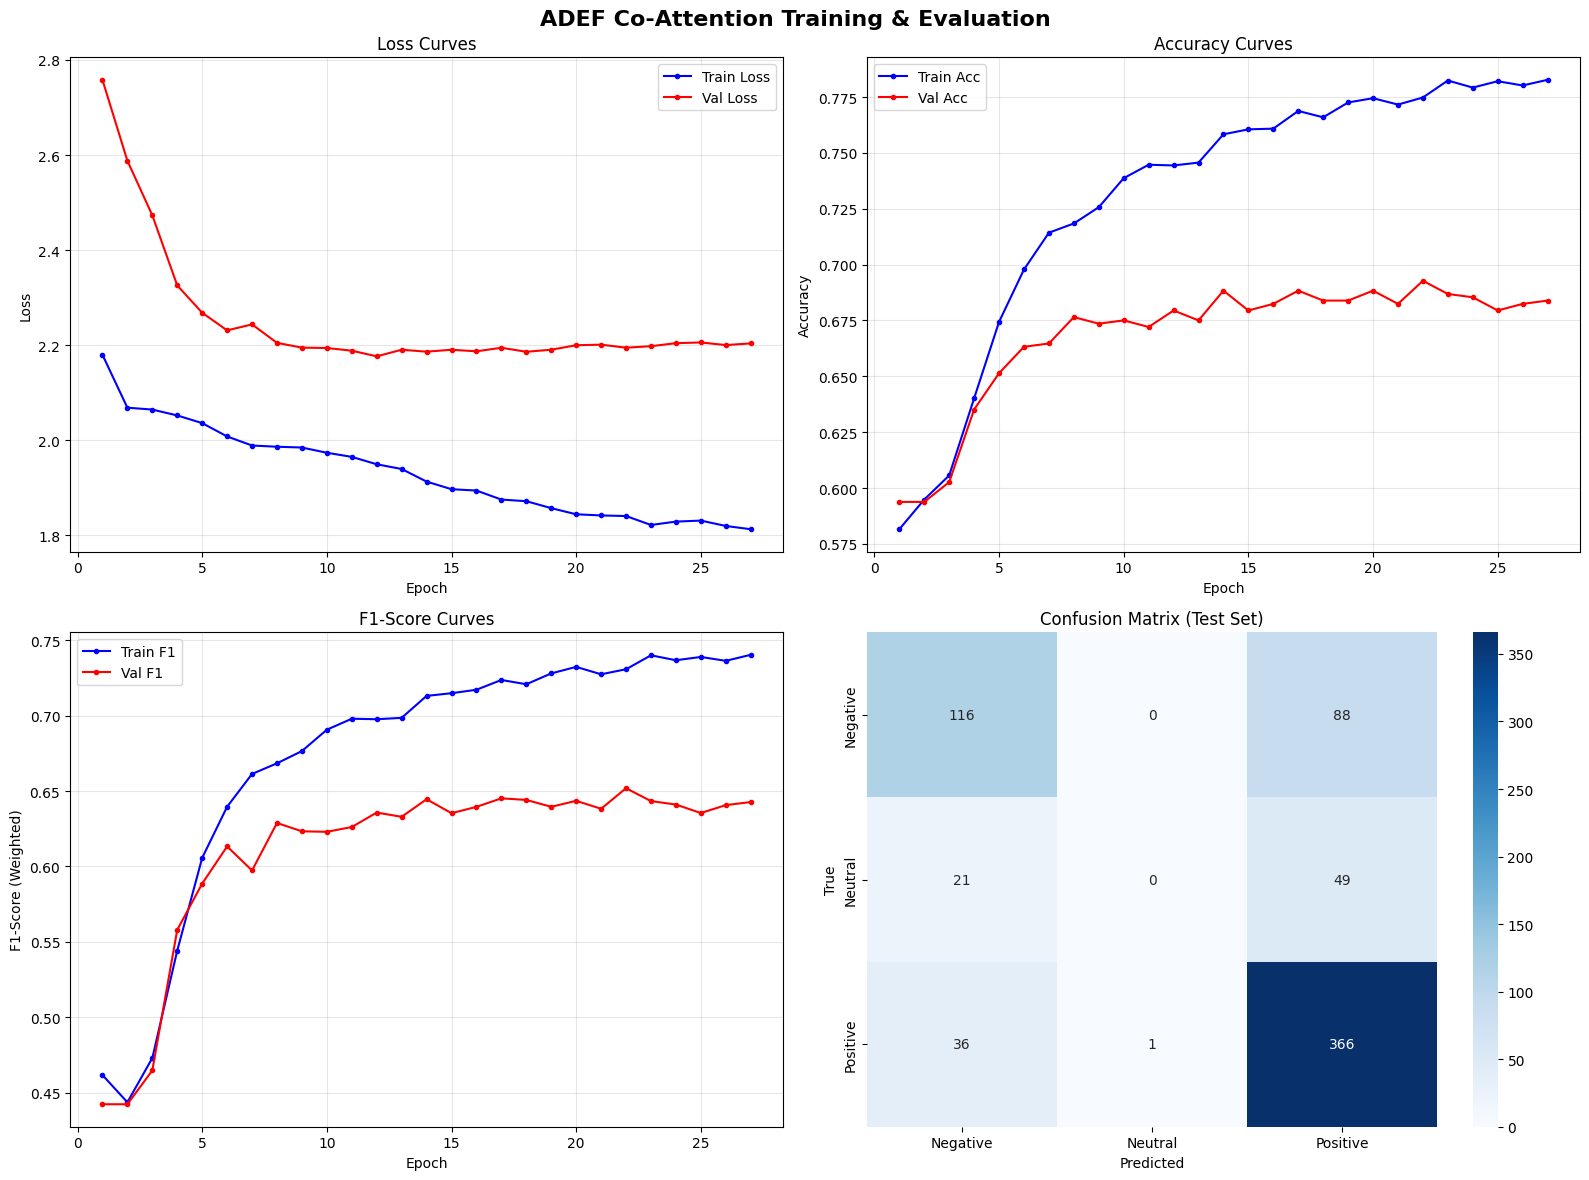

✅ Visualization saved to adef_co_attention_results.png


In [13]:
# ============================================================
# VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("ADEF Co-Attention Training & Evaluation", fontsize=16, fontweight='bold')
epochs_range = range(1, len(history["train_loss"]) + 1)

# --- 1. Loss Curves ---
ax1 = axes[0, 0]
ax1.plot(epochs_range, history["train_loss"], 'b-o', markersize=3, label="Train Loss")
ax1.plot(epochs_range, history["val_loss"], 'r-o', markersize=3, label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss Curves")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- 2. Accuracy Curves ---
ax2 = axes[0, 1]
ax2.plot(epochs_range, history["train_acc"], 'b-o', markersize=3, label="Train Acc")
ax2.plot(epochs_range, history["val_acc"], 'r-o', markersize=3, label="Val Acc")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy Curves")
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- 3. F1-Score Curves ---
ax3 = axes[1, 0]
ax3.plot(epochs_range, history["train_f1"], 'b-o', markersize=3, label="Train F1")
ax3.plot(epochs_range, history["val_f1"], 'r-o', markersize=3, label="Val F1")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("F1-Score (Weighted)")
ax3.set_title("F1-Score Curves")
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- 4. Confusion Matrix ---
ax4 = axes[1, 1]
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
ax4.set_xlabel("Predicted")
ax4.set_ylabel("True")
ax4.set_title("Confusion Matrix (Test Set)")

plt.tight_layout()
plt.savefig("adef_co_attention_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("\u2705 Visualization saved to adef_co_attention_results.png")